In [ ]:
# Import shared data processing functions
import sys
import os
from pathlib import Path
import pickle

# Add the parent directory to the Python path
sys.path.append(str(Path.cwd().parent))

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Import data utilities
from data_utils import load_encoded_data, prepare_modeling_data




In [7]:
# Set base directory
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data"
MODEL_PATH = BASE_DIR / 'models'

In [4]:
dt_tuned = pickle.load(open(MODEL_PATH / 'hr_dt_tuned.pickle', 'rb'))

In [8]:
X = pickle.load(open(DATA_PATH / 'X_features.pickle', 'rb'))

## Feature Importance Analysis

This notebook analyzes feature importance from the decision tree and random forest models.

#### Decision tree splits

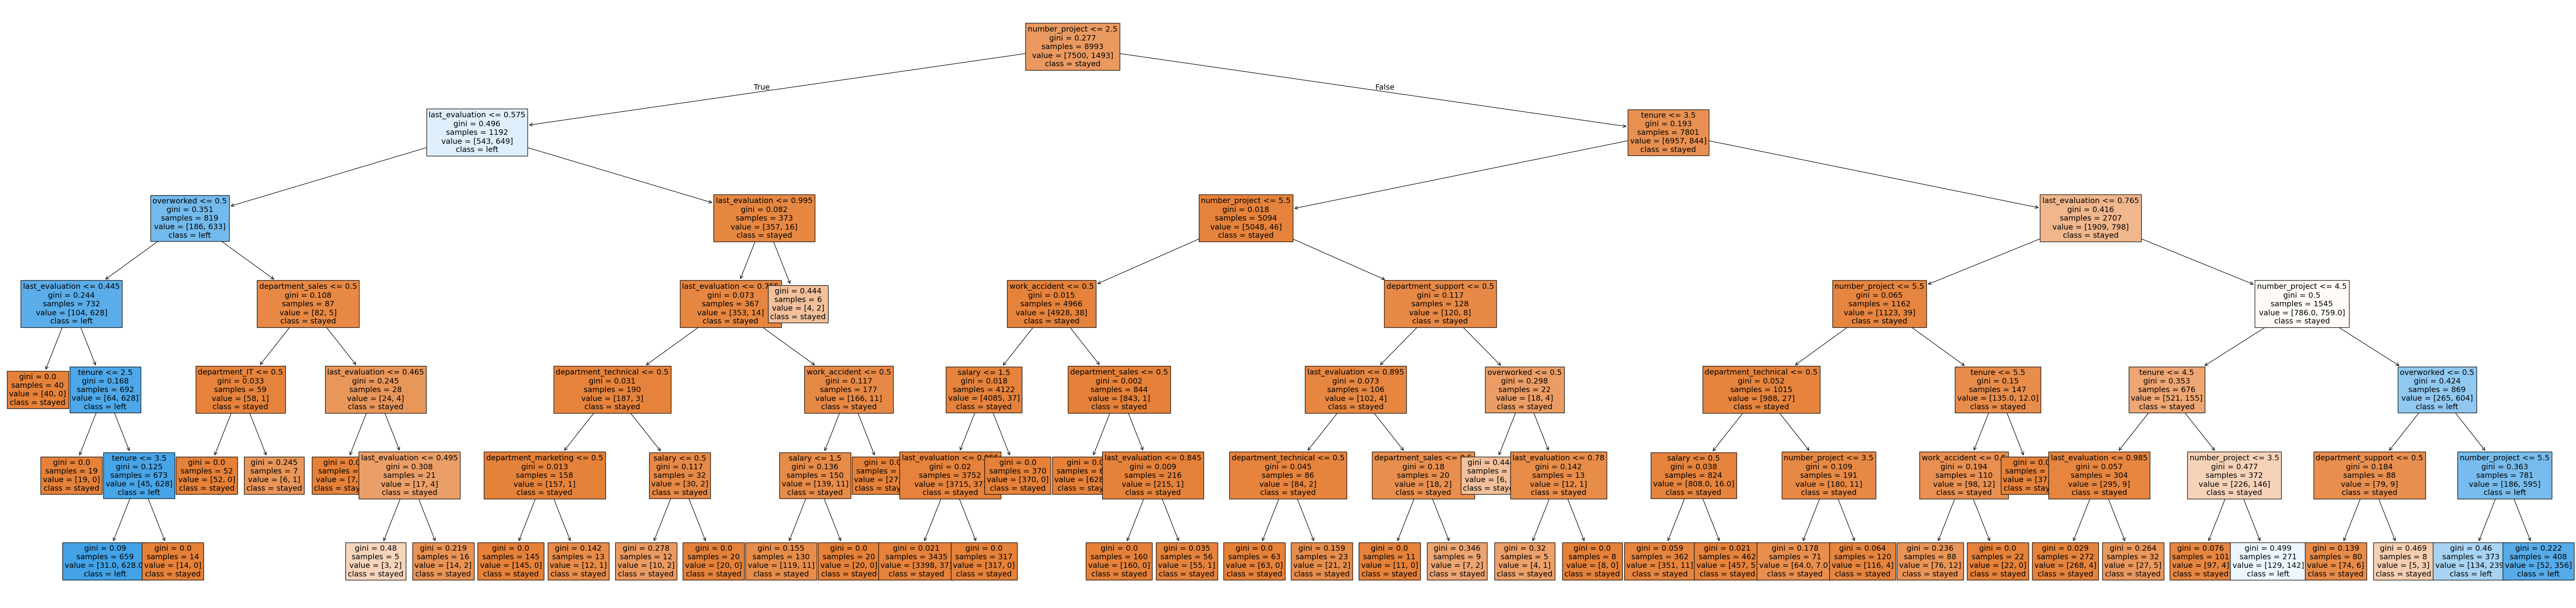

In [9]:
# Plot the tree
plt.figure(figsize=(85,20))
plot_tree(
    dt_tuned.best_estimator_, max_depth=6, fontsize=14, feature_names=X.columns, 
          class_names={0:'stayed', 1:'left'}, filled=True);
plt.show()

Inspect the splits.

#### Decision tree feature importance

You can also get feature importance from decision trees (see the [DecisionTreeClassifier scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_) for details).

In [10]:
#dt_importance = pd.DataFrame(dt_tuned.best_estimator_.feature_importances_, columns=X.columns)
dt_importance = pd.DataFrame(dt_tuned.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
dt_importance = dt_importance.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
dt_importance = dt_importance[dt_importance['gini_importance'] != 0]
dt_importance

,gini_importance
last_evaluation,0.343118
number_project,0.342338
tenure,0.217026
overworked,0.094014
department_support,0.001148
department_sales,0.000610
work_accident,0.000548
salary,0.000492
department_technical,0.000486
department_IT,0.000140


Barplot to visualize the decision tree feature importances.

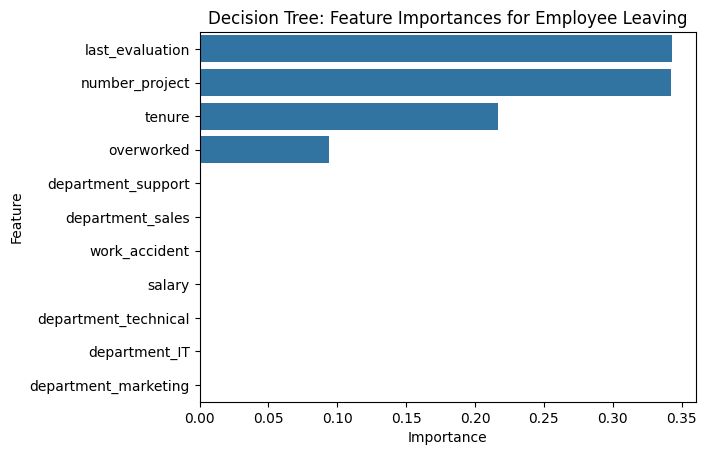

In [11]:
sns.barplot(data=dt_importance, x="gini_importance", y=dt_importance.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()


The barplot above shows that in this decision tree model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`.

#### Random forest feature importance

Plotting the feature importances for the random forest model.

In [ ]:

rf_tuned = pickle.load(open(MODEL_PATH / 'hr_rf_tuned.pickle', 'rb'))

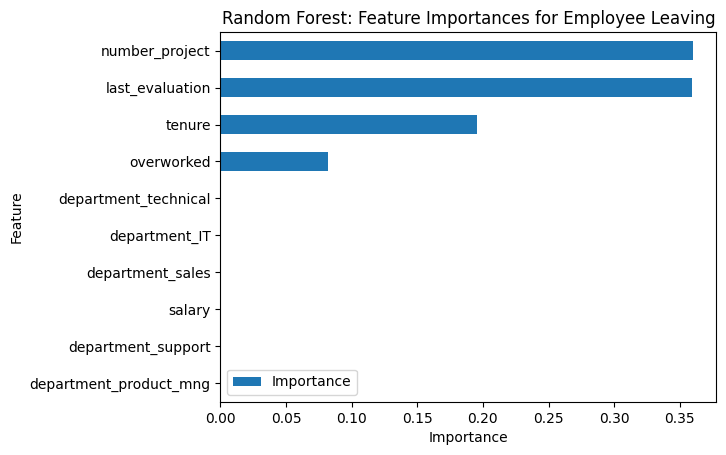

In [14]:
# Get feature importances
feat_impt = rf_tuned.best_estimator_.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(rf_tuned.best_estimator_.feature_importances_, -10)[-10:]

# Get column labels of top 10 features 
feat = X.columns[ind]

# Filter `feat_impt` to consist of top 10 feature importances
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

The plot above shows that in this random forest model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`, and they are the same as the ones used by the decision tree model.

## Results and Evaluation

### Interpreting Model Performance & Results (Focusing on Best Model)



**Best Model:** The Random Forest model demonstrated the strongest performance.

**Key Metrics:**

- AUC: 93.8%  - This indicates an excellent ability to distinguish between employees who will leave and those who will stay.

- Precision: 87.0%  - This shows when the model predicts an employee will leave, it's correct around 87% (or more) of the time.

- Recall: 90.36%  - The model successfully identifies about 90% (or more) of employees who actually end up leaving.

- F1-Score: 88.7%  - This shows a strong balance between precision and recall.

- Accuracy: 96.2% .Overall, the model makes correct predictions (leave/stay) for a very high percentage of employees.

### Summary of model results

**Logistic Regression**

The logistic regression model achieved precision of 80%, recall of 83%, f1-score of 80% (all weighted averages), and accuracy of 83%, on the test set.

**Tree-based Machine Learning**

After conducting feature engineering, the decision tree model achieved AUC of 93.8%, precision of 87.0%, recall of 90.4%, f1-score of 88.7%, and accuracy of 96.2%, on the test set. The random forest modestly outperformed the decision tree model. 